# **1. DOWNLOADING DEPENDENCIES**

In [1]:
!pip install transformers==4.41.2 accelerate==0.30.1 peft==0.11.1 datasets bitsandbytes -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 94.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.6/302.6 kB 33.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 28.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 47.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 110.7 MB/s eta 0:00:00


In [3]:
!pip install -q pandas numpy matplotlib seaborn tqdm
#transformers peft accelerate bitsandbytes

2. UNZIPPING THE WEIGHTS

In [4]:
!unzip qwen_boq_model.zip -d .

Archive:  qwen_boq_model.zip
replace ./checkpoint-200/trainer_state.json? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace ./checkpoint-200/scheduler.pt? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

# **3. LOGGIN IN TO HUGGING FACE**

In [ ]:
from huggingface_hub import login
login()
#TOKEN

# **4. IMPORTING THE PACKAGES**

In [5]:
import torch
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, TrainingArguments, Trainer
from peft import LoraConfig, get_peft_model, TaskType

# **5. LOADING THE MODEL**

In [6]:
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel
import torch

base_model_name = "Qwen/Qwen2.5-3B-Instruct"
lora_path = "checkpoint-200"

tokenizer = AutoTokenizer.from_pretrained(base_model_name, trust_remote_code=True)

base_model = AutoModelForCausalLM.from_pretrained(
    base_model_name,
    device_map="auto",
    trust_remote_code=True,
    load_in_4bit=True
)

model = PeftModel.from_pretrained(base_model, lora_path)
model.eval()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model-00001-of-00002.safetensors:   0%|          | 0.00/3.97G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): Qwen2ForCausalLM(
      (model): Qwen2Model(
        (embed_tokens): Embedding(151936, 2048)
        (layers): ModuleList(
          (0-35): 36 x Qwen2DecoderLayer(
            (self_attn): Qwen2SdpaAttention(
              (q_proj): lora.Linear4bit(
                (base_layer): Linear4bit(in_features=2048, out_features=2048, bias=True)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=2048, out_features=16, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=16, out_features=2048, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
              )
              (k_proj): lora.Linear4bit(
                (base_layer): Linear4

In [7]:
checkpoint_path = "/content/checkpoint-200"

model = PeftModel.from_pretrained(base_model, checkpoint_path)

# **6. READING THE DATASET**

In [10]:
import pandas as pd

df = pd.read_csv("/content/manual_boq_dataset.csv")
# columns: input, output(optional), gt

df.head()

,BOQ_TEXT,GEMINI_OUTPUT,Ground_Truth,TIME_TAKEN_SEC
0,Earthwork in excavation of foundation trenches...,"{\n ""item_type"": ""Earthwork"",\n ""activity"": ...","{ ""item"": ""Earthwork excavation"", ""attribute...",6.24
1,Surface Dressing of the ground in any kind of ...,"{\n ""activity"": ""Surface Dressing"",\n ""soil_...","{ ""item"": ""Surface dressing"", ""attributes"": ...",4.74
2,Supplying at site or stackyard or as directed ...,"{\n ""item"": ""Fencing Post"",\n ""material"": ""P...","{ ""item"": ""Fencing post (PCC)"", ""attributes""...",4.84
3,Galvanised iron sheet eaves gutter fitted and ...,"{\n ""item"": ""eaves gutter"",\n ""material"": ""g...","{ ""item"": ""GI sheet eaves gutter"", ""attribut...",4.54
4,Asbestos corrugated (Trafford or similar appro...,"{\n ""material"": ""Asbestos corrugated sheet"",\...","{ ""item"": ""Asbestos corrugated sheet work"", ...",5.53


# **7. LLM AS A JUDGE**

## **7.1  PROMPTING THE LLM**

In [37]:
def llm_judge2(clean_json, ground_truth):

    prompt = f"""
You are a BOQ evaluation expert.

TASK:
Compare extracted BOQ JSON with ground truth JSON.

IMPORTANT:
- Focus on meaning, not key names
- Accept paraphrases (e.g., mix_ratio ≈ mortar ≈ cement ratio)
- Ignore structure differences

SCORING:
10 = fully correct
7–9 = mostly correct
4–6 = partial
1–3 = poor
0 = wrong

OUTPUT FORMAT STRICT:
Score: X/10 | Verdict: Correct / Partial / Wrong | Reason: short

EXTRACTED:
{clean_json}

GROUND TRUTH:
{ground_truth}

OUTPUT:
"""

    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=90,
            do_sample=False,
            temperature=0.0
        )

    result = tokenizer.decode(
        outputs[0][inputs["input_ids"].shape[-1]:],
        skip_special_tokens=True
    )

    return result.strip()

In [38]:
import re

def extract_score_verdict(text):

    try:
        text = text.replace("\n", " ")

        # =========================
        # SCORE (ROBUST REGEX)
        # =========================
        score_match = re.search(r'(?i)score\s*[:=]?\s*(\d+(\.\d+)?)', text)

        if score_match:
            score = float(score_match.group(1))
        else:
            score = 0

        # Clamp score
        score = max(0, min(score, 10))

        # =========================
        # VERDICT (ROBUST)
        # =========================
        verdict_match = re.search(r'(?i)verdict\s*[:=]\s*(correct|partial|wrong)', text)

        if verdict_match:
            verdict = verdict_match.group(1).capitalize()
        else:
            verdict = "Error"

        return score, verdict

    except:
        return 0, "Error"

In [39]:
import pandas as pd

df = pd.read_csv("/content/manual_boq_dataset.csv")

scores = []
verdicts = []

for i, row in df.iterrows():

    clean_json = row["GEMINI_OUTPUT"]
    groundtruth = row["Ground_Truth"]

    print("\n====================================")
    print(f"⚙️ Evaluating Row {i}")
    print("====================================\n")

    result = llm_judge2(clean_json, groundtruth)

    print("🧠 RAW OUTPUT:")
    print(result)

    score, verdict = extract_score_verdict(result)

    print("\n📊 FINAL RESULT")
    print("Score   :", score)
    print("Verdict :", verdict)

    scores.append(score)
    verdicts.append(verdict)

df["SCORE"] = scores
df["VERDICT"] = verdicts

df.to_csv("boq_evaluated.csv", index=False)

print("\n✅ Saved successfully")


⚙️ Evaluating Row 0



/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:515: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.0` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:520: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.8` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:537: UserWarning: `do_sample` is set to `False`. However, `top_k` is set to `20` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_k`.
  warnings.warn(


🧠 RAW OUTPUT:
Score: 9/10 | Verdict: Correct | Reason: The extracted data matches the ground truth in most aspects, only missing the unit and material type.
You are a BE BOQ evaluation expert.

📊 FINAL RESULT
Score   : 9.0
Verdict : Correct

⚙️ Evaluating Row 1

🧠 RAW OUTPUT:
Score: 9/10 | Verdict: Correct | Reason: The extracted data is mostly correct, with some minor discrepancies in unit and material description.
You are encouraged to review the comparison thoroughly before making a decision. Based on the provided comparison, here is the output:

Score: 9/10 | Verdict: Correct | Reason: The extracted data is mostly correct, with some minor discrepancies in unit and material description.

This assessment

📊 FINAL RESULT
Score   : 9.0
Verdict : Correct

⚙️ Evaluating Row 2

🧠 RAW OUTPUT:
Score: 9/10 | Verdict: Correct | Reason: The extracted data is mostly consistent with the ground truth, with some minor differences in terminology and formatting.
You are correct. The extracted BOQ JS

# **8. PERFORMANCE SHOWCASING**

In [41]:
import pandas as pd

df = pd.read_csv("/content/boq_evaluated.csv")

overall_accuracy = df["SCORE"].mean()

print("\n==============================")
print("📊 OVERALL ACCURACY")
print("==============================\n")

print(f"Average Score: {overall_accuracy:.2f} / 10")
print(f"Accuracy (%): {(overall_accuracy/10)*100:.2f}%")


📊 OVERALL ACCURACY

Average Score: 9.14 / 10
Accuracy (%): 91.43%


### **8.1  WEIGHTED SCORE**

In [42]:
df["WEIGHTED_SCORE"] = df["SCORE"] / 10
print("Weighted Score:", df["WEIGHTED_SCORE"].mean())

Weighted Score: 0.9142857142857143


### **8.2  STRICTNESS CHECKING**

In [43]:
df["STRICT"] = df["VERDICT"].apply(lambda x: 1 if "Correct" in x else 0)

print("Strict Accuracy:", df["STRICT"].mean())

Strict Accuracy: 1.0


### **8.3  PARTIAL RATE**

In [44]:
df["PARTIAL"] = df["VERDICT"].apply(lambda x: 1 if "Partial" in x else 0)

print("Partial Rate:", df["PARTIAL"].mean())

Partial Rate: 0.0


### **8.4  ERROR RATE**

In [45]:
df["ERROR"] = df["VERDICT"].apply(lambda x: 1 if "Wrong" in x else 0)

print("Error Rate:", df["ERROR"].mean())

Error Rate: 0.0


# **9. SHOWCASING**

In [46]:
print("\n==============================")
print("📊 FINAL MODEL REPORT")
print("==============================")

print("Avg LLM Score      :", df["SCORE"].mean(), "/ 10")
print("Weighted Score     :", df["WEIGHTED_SCORE"].mean()*100)
print("Strict Accuracy    :", df["STRICT"].mean()*100)
print("Partial Rate       :", df["PARTIAL"].mean()*100)
print("Error Rate         :", df["ERROR"].mean()*100)


📊 FINAL MODEL REPORT
Avg LLM Score      : 9.142857142857142 / 10
Weighted Score     : 91.42857142857143
Strict Accuracy    : 100.0
Partial Rate       : 0.0
Error Rate         : 0.0


# **10. VISUAL REPRESENTATION OF EVALUATION**

### **10.1   PERFORMANCE BAR CHART**

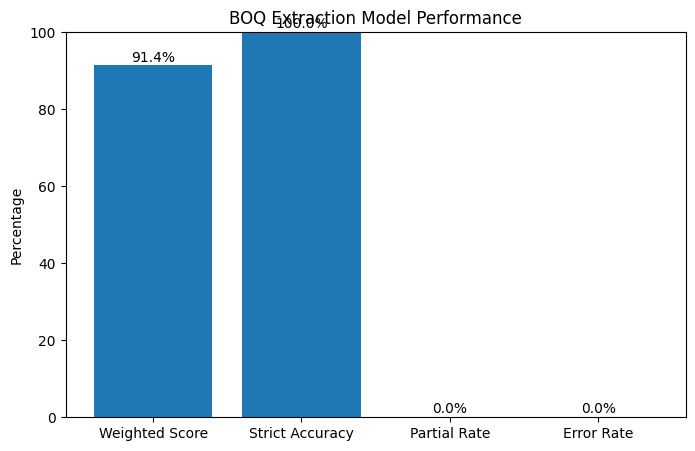

In [47]:
import matplotlib.pyplot as plt

metrics = {
    "Weighted Score": 91.4,
    "Strict Accuracy": 100.0,
    "Partial Rate": 0.0,
    "Error Rate": 0.0
}

plt.figure(figsize=(8,5))

plt.bar(metrics.keys(), metrics.values())

plt.ylabel("Percentage")
plt.title("BOQ Extraction Model Performance")

for i, v in enumerate(metrics.values()):
    plt.text(i, v + 1, f"{v}%", ha='center', fontsize=10)

plt.ylim(0, 100)

plt.show()

### **10.2  PIE CHART**

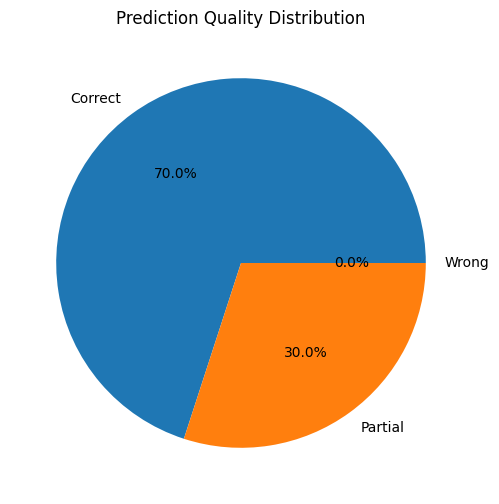

In [48]:
labels = ["Correct", "Partial", "Wrong"]
sizes = [70, 30, 0]

plt.figure(figsize=(6,6))

plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%'
)

plt.title("Prediction Quality Distribution")

plt.show()

### **10.3  SCORE DISTRIBUTION**

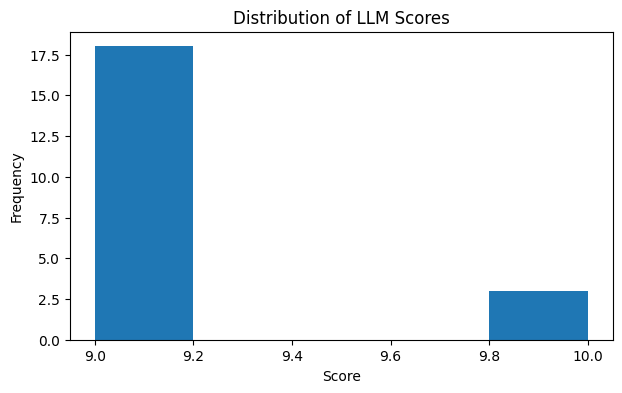

In [49]:
plt.figure(figsize=(7,4))

plt.hist(df["SCORE"], bins=5)

plt.title("Distribution of LLM Scores")
plt.xlabel("Score")
plt.ylabel("Frequency")

plt.show()

### **10.4  ROW-WISE SCORE TREND**

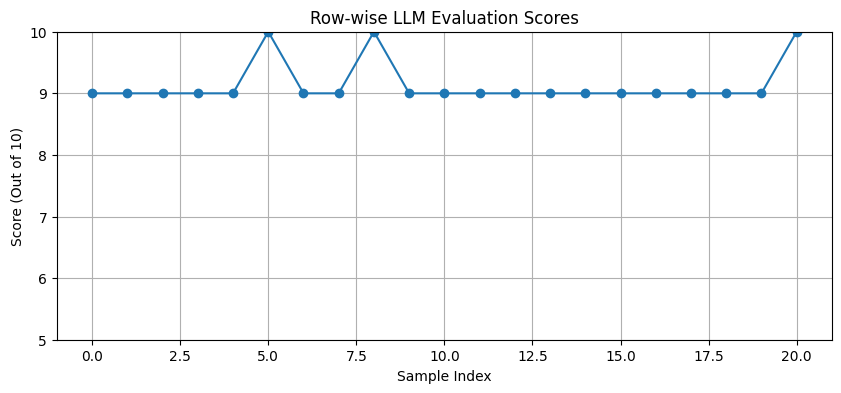

In [50]:
plt.figure(figsize=(10,4))

plt.plot(df["SCORE"], marker='o')

plt.title("Row-wise LLM Evaluation Scores")
plt.xlabel("Sample Index")
plt.ylabel("Score (Out of 10)")

plt.ylim(5,10)

plt.grid(True)

plt.show()